<a href="https://colab.research.google.com/github/M-Usaid1/Linear-regression-Salarydata/blob/main/LinearRegression(SalaryData).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

#Dataset Imported

In [ ]:
dataset = pd.read_csv('Salary Data.csv')

In [ ]:
dataset.shape

(30, 2)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


#Data Pre-processing

In [ ]:
dataset.Salary.unique()

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

In [ ]:
dataset.YearsExperience.unique()

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.7,  3.9,  4. ,
        4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,  7.9,  8.2,
        8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [ ]:
X = dataset.drop('Salary', axis = 1)
y = dataset['Salary']

In [ ]:
#Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#ML Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('model',LinearRegression())
])

#Model training

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', LinearRegression())])

###Pediction of model

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
#random prediction
print(pipeline.predict([[7]]))

[91288.29027299]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#Evaluation(Error checking)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
#very less, near to none

49830096.85590839
6286.453830757749
0.9024461774180497


###Let's Visualize

In [ ]:
import matplotlib.pyplot as plt

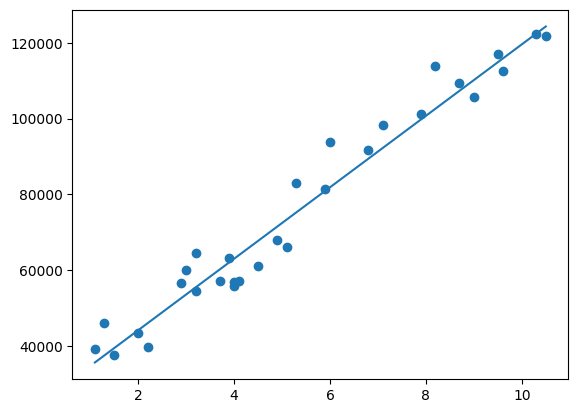

In [ ]:
plt.scatter(X, y)
plt.plot(X, pipeline.predict(X))
plt.show()

#Save as pickle file

In [ ]:
import pickle

In [ ]:
with open("salary_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [ ]:
with open("salary_model.pkl", "rb") as f:
    model = pickle.load(f)

model.predict([[5]])   # predict for 5 years

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([72440.65962693])